In [2]:
import pandas as pd

df = pd.read_csv('online_retail.csv', encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:

df.shape

(541909, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
# 1. Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# 2. Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 3. Remove cancelled invoices (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# 4. Remove negative or zero Quantity and UnitPrice
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Check result
df.shape

(397884, 8)

In [7]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(5192)

In [9]:
df = df.drop_duplicates()
df.shape

(392692, 8)

In [10]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64


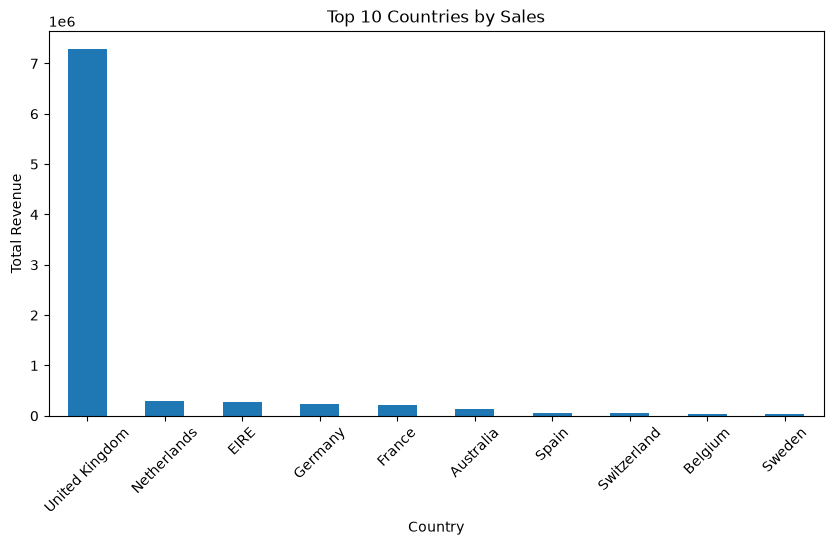

In [11]:
import matplotlib.pyplot as plt

country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(country_sales)

plt.figure(figsize=(10,5))
country_sales.plot(kind='bar')
plt.title('Top 10 Countries by Sales')
plt.ylabel('Total Revenue')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.show()

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


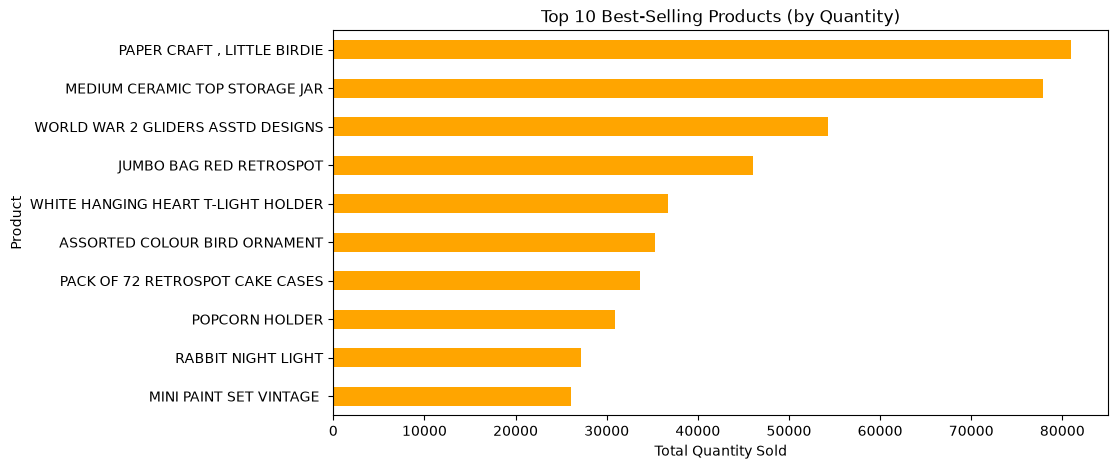

In [12]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_products)

plt.figure(figsize=(10,5))
top_products.plot(kind='barh', color='orange')
plt.title('Top 10 Best-Selling Products (by Quantity)')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.gca().invert_yaxis()
plt.show()

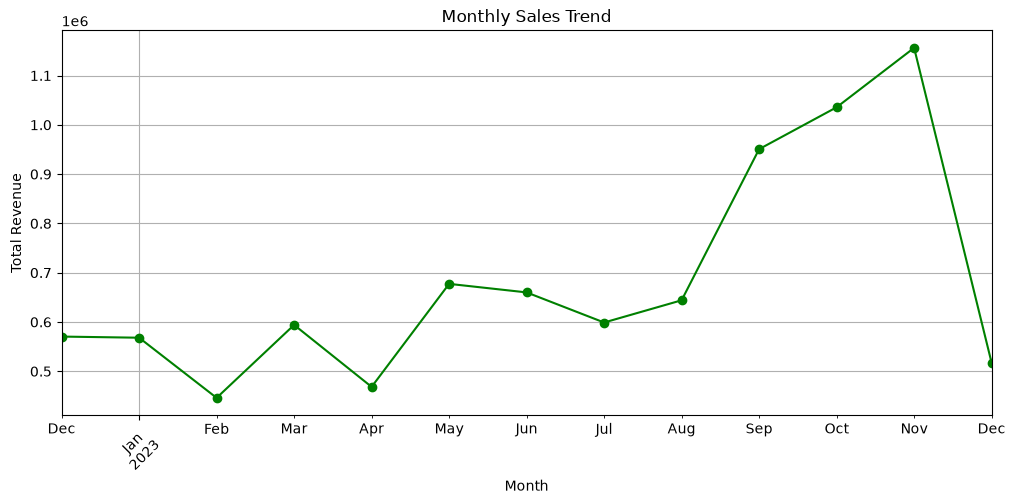

In [13]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(kind='line', marker='o', color='green')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [14]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


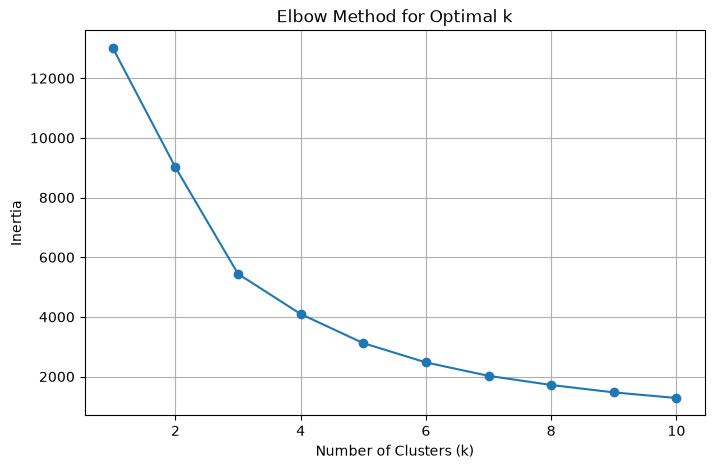

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Scale the RFM values
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Elbow Method - try k from 1 to 10
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [16]:
from sklearn.metrics import silhouette_score

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(f"k={k}, Silhouette Score={score:.3f}")

k=2, Silhouette Score=0.896
k=3, Silhouette Score=0.594
k=4, Silhouette Score=0.616
k=5, Silhouette Score=0.617
k=6, Silhouette Score=0.598


In [17]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1353.625312
1,248.075914,1.552015,478.848773
2,7.384615,82.538462,127187.959231
3,15.500000,22.333333,12690.500392


In [18]:
cluster_labels = {
    2: 'High-Value',
    3: 'Regular',
    0: 'Occasional',
    1: 'At-Risk'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_labels)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,1,77183.60,3,Regular
1,12347.0,2,7,4310.00,0,Occasional
2,12348.0,75,4,1797.24,0,Occasional
3,12349.0,19,1,1757.55,0,Occasional
4,12350.0,310,1,334.40,1,At-Risk


Segment
Occasional    3054
At-Risk       1067
Regular        204
High-Value      13
Name: count, dtype: int64


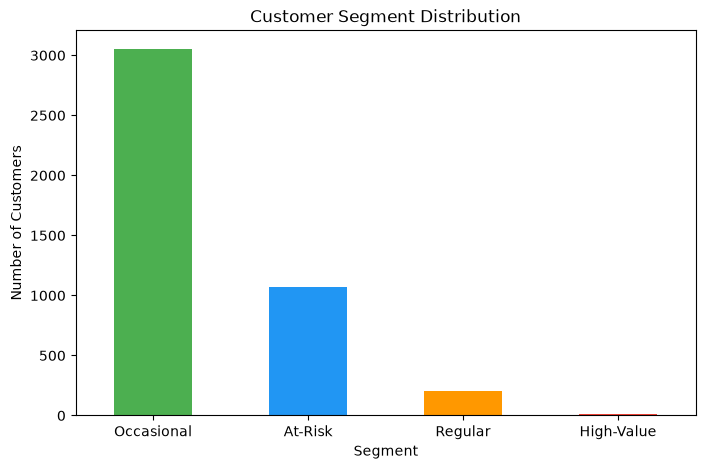

In [19]:
segment_counts = rfm['Segment'].value_counts()
print(segment_counts)

plt.figure(figsize=(8,5))
segment_counts.plot(kind='bar', color=['#4CAF50','#2196F3','#FF9800','#F44336'])
plt.title('Customer Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

In [20]:
import pickle

# Save the scaler and kmeans model
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(kmeans, open('kmeans_model.pkl', 'wb'))

# Save the RFM dataframe with segments
rfm.to_csv('rfm_segments.csv', index=False)

print("Saved successfully!")

Saved successfully!


In [21]:
# Create a pivot table: rows = CustomerID, columns = Product, values = Quantity
customer_product = df.pivot_table(
    index='CustomerID', 
    columns='Description', 
    values='Quantity', 
    aggfunc='sum', 
    fill_value=0
)

customer_product.shape

(4338, 3877)

In [22]:
from sklearn.metrics.pairwise import cosine_similarity

# Transpose so that rows = Products, columns = Customers
product_customer = customer_product.T

# Calculate cosine similarity between products
similarity_matrix = cosine_similarity(product_customer)

# Convert to DataFrame for easy lookup
similarity_df = pd.DataFrame(similarity_matrix, index=product_customer.index, columns=product_customer.index)

similarity_df.shape

(3877, 3877)

In [23]:
def recommend_products(product_name, top_n=5):
    if product_name not in similarity_df.columns:
        return "Product not found. Check spelling (all caps usually)."
    
    similar_scores = similarity_df[product_name].sort_values(ascending=False)
    similar_scores = similar_scores.drop(product_name)  # remove itself
    return similar_scores.head(top_n)

# Test with a product from your dataset
recommend_products('WHITE HANGING HEART T-LIGHT HOLDER')

Description
GIN + TONIC DIET METAL SIGN         0.750192
RED HANGING HEART T-LIGHT HOLDER    0.658714
WASHROOM METAL SIGN                 0.643520
LAUNDRY 15C METAL SIGN              0.642200
GREEN VINTAGE SPOT BEAKER           0.631463
Name: WHITE HANGING HEART T-LIGHT HOLDER, dtype: float64

In [24]:
import pickle

pickle.dump(similarity_df, open('similarity_matrix.pkl', 'wb'))
print("Saved successfully!")

Saved successfully!


In [25]:
total_revenue = df['TotalPrice'].sum()
avg_spending = df.groupby('CustomerID')['TotalPrice'].sum().mean()
top_country = df.groupby('Country')['TotalPrice'].sum().idxmax()
best_product = df.groupby('Description')['Quantity'].sum().idxmax()

print(f"Total Revenue: £{total_revenue:,.0f}")
print(f"Average Customer Spending: £{avg_spending:,.0f}")
print(f"Top Country: {top_country}")
print(f"Best Selling Product: {best_product}")

Total Revenue: £8,887,209
Average Customer Spending: £2,049
Top Country: United Kingdom
Best Selling Product: PAPER CRAFT , LITTLE BIRDIE
